## Part A : Handling Missing Values

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer , MissingIndicator , KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [2]:
df = pd.read_csv('Data\\patient_dataset.csv')
df

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,80.0,Female,West,33.3,176.4,191.5,236.2,1
1,2,26.0,Male,North,22.3,160.0,121.2,116.8,1
2,3,24.0,Female,East,38.8,164.2,151.5,148.3,1
3,4,48.0,Male,East,30.3,99.8,143.9,124.0,1
4,5,78.0,Female,West,16.3,109.5,126.9,74.0,1
...,...,...,...,...,...,...,...,...,...
995,996,49.0,Female,North,21.6,165.4,136.0,159.2,1
996,997,85.0,Female,South,25.2,139.1,220.1,202.7,1
997,998,54.0,Female,South,26.8,163.4,225.8,129.4,1
998,999,37.0,Female,North,26.8,115.7,277.4,117.7,1


In [3]:
df.isnull().sum()

patient_id         0
age               40
gender            30
region            25
bmi               25
blood_pressure     0
cholesterol       20
glucose           20
disease_risk       0
dtype: int64

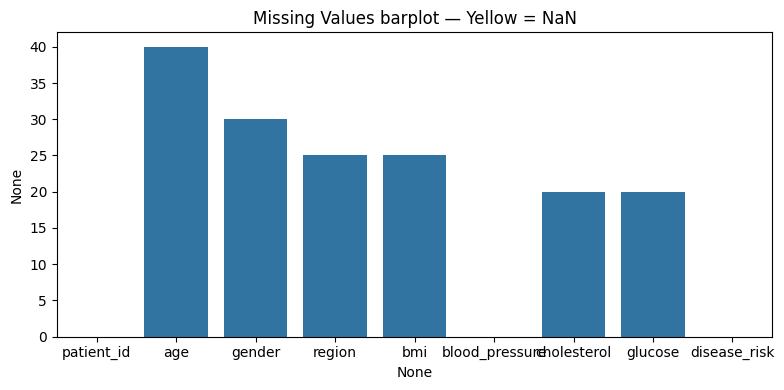

In [4]:
# missing values barplot
    
plt.figure(figsize=(8, 4))
sns.barplot(x=df.columns, y=df.isnull().sum())
plt.title('Missing Values barplot — Yellow = NaN')
plt.tight_layout()
plt.show()

## 1. Summary report(perchantage per column)

In [5]:
missing_pct = df.isnull().sum() / len(df) * 100

In [6]:
print("Percentage of Missing Values in Each Column : ")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

Percentage of Missing Values in Each Column : 
age            4.0
gender         3.0
region         2.5
bmi            2.5
cholesterol    2.0
glucose        2.0
dtype: float64


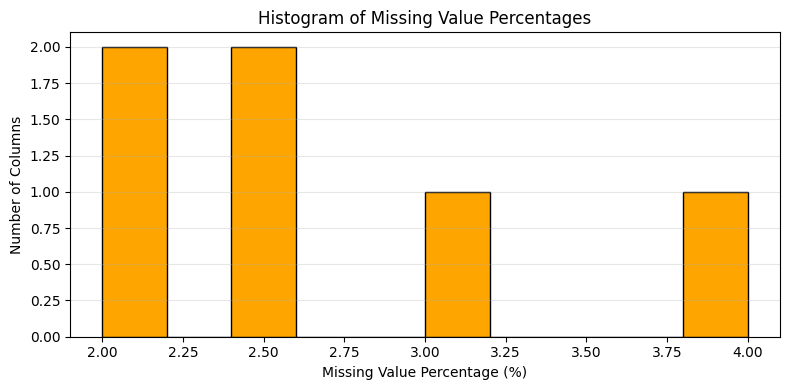

In [7]:
# Histogram of missing value percentages
plt.figure(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(
    kind='hist',
    bins=10,
    color='orange',
    edgecolor='black'
)

plt.title("Histogram of Missing Value Percentages")
plt.xlabel("Missing Value Percentage (%)")
plt.ylabel("Number of Columns")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. imputation techniques and compare results

In [8]:
# Mean Imputation
mean_imputer = SimpleImputer(strategy='mean')

df_mean = pd.DataFrame(
    mean_imputer.fit_transform(df['bmi'].values.reshape(-1, 1)),
    columns=['bmi']
)

In [9]:
print("After Mean Imputation : ")
print(df_mean)

After Mean Imputation : 
      bmi
0    33.3
1    22.3
2    38.8
3    30.3
4    16.3
..    ...
995  21.6
996  25.2
997  26.8
998  26.8
999  19.5

[1000 rows x 1 columns]


In [10]:
# frequent imputer
freq_imputer = SimpleImputer(strategy='most_frequent')

df_freq = pd.DataFrame(
    freq_imputer.fit_transform(df['bmi'].values.reshape(-1, 1)),
    columns=['bmi']
)

print("After Frequent Imputation for BMI : ")
print(df_freq)

After Frequent Imputation for BMI : 
      bmi
0    33.3
1    22.3
2    38.8
3    30.3
4    16.3
..    ...
995  21.6
996  25.2
997  26.8
998  26.8
999  19.5

[1000 rows x 1 columns]


In [11]:
# frequent imputer gender

freq_imputer = SimpleImputer(strategy='most_frequent')

df_freq_gender = pd.DataFrame(
    freq_imputer.fit_transform(df['gender'].values.reshape(-1, 1)),
    columns=['gender']
)

print("After Frequent Imputation for Gender : ")
print(df_freq_gender)


After Frequent Imputation for Gender : 
     gender
0    Female
1      Male
2    Female
3      Male
4    Female
..      ...
995  Female
996  Female
997  Female
998  Female
999  Female

[1000 rows x 1 columns]


In [12]:
# Missing Indicator

indicator = MissingIndicator(features='missing-only')
indicator_array = indicator.fit_transform(df)
print("Indicator array shape:", indicator_array.shape)

indicator_cols = [df.columns[i] + '_Missing' for i in indicator.features_]
df_indicator = pd.DataFrame(indicator_array.astype(int), columns=indicator_cols)

imputer = SimpleImputer(strategy='constant')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_final = pd.concat([df_imputed, df_indicator], axis=1)


Indicator array shape: (1000, 6)


In [13]:
# random sample impute

def random_sample_impute(df, col, random_state=7):
    np.random.seed(random_state)

    null_count = df[col].isnull().sum()

    if null_count == 0:
        return df  

    random_values = df[col].dropna().sample(
        n=null_count,        
        replace=True,        
        random_state=random_state
    ).values
    
    df_copy = df.copy()
    df_copy.loc[df_copy[col].isnull(), col] = random_values

    return df_copy

num_cols = ['age','bmi', 'blood_pressure', 'cholesterol	','glucose','disease_risk']
df_imputed = df.copy()

In [14]:
print("After Random Sample Imputation : ")
print(df_imputed)

After Random Sample Imputation : 
     patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0             1  80.0  Female   West  33.3           176.4        191.5   
1             2  26.0    Male  North  22.3           160.0        121.2   
2             3  24.0  Female   East  38.8           164.2        151.5   
3             4  48.0    Male   East  30.3            99.8        143.9   
4             5  78.0  Female   West  16.3           109.5        126.9   
..          ...   ...     ...    ...   ...             ...          ...   
995         996  49.0  Female  North  21.6           165.4        136.0   
996         997  85.0  Female  South  25.2           139.1        220.1   
997         998  54.0  Female  South  26.8           163.4        225.8   
998         999  37.0  Female  North  26.8           115.7        277.4   
999        1000   NaN  Female    NaN  19.5           101.1        307.7   

     glucose  disease_risk  
0      236.2             1  
1      

In [15]:
# KNN Imputer

num_cols = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'disease_risk']

knn_imputer = KNNImputer(n_neighbors=3)
df_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df[num_cols]),
    columns=num_cols
)
df_knn_imputed = df_knn_imputed.round(2)
print("After KNN Imputation (k=3) : ")
print(df_knn_imputed)


After KNN Imputation (k=3) : 
      age   bmi  blood_pressure  cholesterol  glucose  disease_risk
0    80.0  33.3           176.4        191.5    236.2           1.0
1    26.0  22.3           160.0        121.2    116.8           1.0
2    24.0  38.8           164.2        151.5    148.3           1.0
3    48.0  30.3            99.8        143.9    124.0           1.0
4    78.0  16.3           109.5        126.9     74.0           1.0
..    ...   ...             ...          ...      ...           ...
995  49.0  21.6           165.4        136.0    159.2           1.0
996  85.0  25.2           139.1        220.1    202.7           1.0
997  54.0  26.8           163.4        225.8    129.4           1.0
998  37.0  26.8           115.7        277.4    117.7           1.0
999  73.0  19.5           101.1        307.7     87.8           1.0

[1000 rows x 6 columns]


In [16]:
# MICE Algorithm

imputer = IterativeImputer(max_iter=10, random_state=0)

df_mice_imputed = pd.DataFrame(
    imputer.fit_transform(df[num_cols]),
    columns=num_cols
)

print("After MICE Imputation : ")
print(df_mice_imputed.round(4))

After MICE Imputation : 
         age   bmi  blood_pressure  cholesterol   glucose  disease_risk
0    80.0000  33.3           176.4        191.5  236.2000           1.0
1    26.0000  22.3           160.0        121.2  116.8000           1.0
2    24.0000  38.8           164.2        151.5  148.3000           1.0
3    48.0000  30.3            99.8        143.9  124.0000           1.0
4    78.0000  16.3           109.5        126.9   74.0000           1.0
..       ...   ...             ...          ...       ...           ...
995  49.0000  21.6           165.4        136.0  159.2000           1.0
996  85.0000  25.2           139.1        220.1  202.7000           1.0
997  54.0000  26.8           163.4        225.8  129.4000           1.0
998  37.0000  26.8           115.7        277.4  117.7000           1.0
999  51.1025  19.5           101.1        307.7  162.5258           1.0

[1000 rows x 6 columns]


## Part B : Handling Outliers

### 3. Detect and Remove outliers using : 

In [17]:
# Z score method

df_Mean_Cl = df[['cholesterol']].mean()
df_Std_Cl = df[['cholesterol']].std()

df_Mean_Gl = df[['glucose']].mean()
df_Std_Gl = df[['glucose']].std()

print("Mean and Standard Deviation for Cholesterol : ")
print("Mean:", df_Mean_Cl.values[0])
print("Standard Deviation:", df_Std_Cl.values[0])

print("\nMean and Standard Deviation for Glucose : ")
print("Mean:", df_Mean_Gl.values[0])
print("Standard Deviation:", df_Std_Gl.values[0])

Mean and Standard Deviation for Cholesterol : 
Mean: 213.63418367346938
Standard Deviation: 57.69109565365385

Mean and Standard Deviation for Glucose : 
Mean: 156.76377551020408
Standard Deviation: 48.419883851857676


In [18]:
# IQR method bmi

Q1 = df['bmi'].quantile(0.25)   
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1


In [19]:
Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

print("Lower Bound for BMI:", Lower_Bound)
print("Upper Bound for BMI:", Upper_Bound)

Lower Bound for BMI: 1.2499999999999964
Upper Bound for BMI: 53.650000000000006


In [20]:
df_cleaned = df[(df['bmi'] >= Lower_Bound) & (df['bmi'] <= Upper_Bound)]
print("Cleaned DataFrame shape:", df_cleaned.shape)



Cleaned DataFrame shape: (975, 9)


In [21]:
df_cleaned

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,80.0,Female,West,33.3,176.4,191.5,236.2,1
1,2,26.0,Male,North,22.3,160.0,121.2,116.8,1
2,3,24.0,Female,East,38.8,164.2,151.5,148.3,1
3,4,48.0,Male,East,30.3,99.8,143.9,124.0,1
4,5,78.0,Female,West,16.3,109.5,126.9,74.0,1
...,...,...,...,...,...,...,...,...,...
995,996,49.0,Female,North,21.6,165.4,136.0,159.2,1
996,997,85.0,Female,South,25.2,139.1,220.1,202.7,1
997,998,54.0,Female,South,26.8,163.4,225.8,129.4,1
998,999,37.0,Female,North,26.8,115.7,277.4,117.7,1


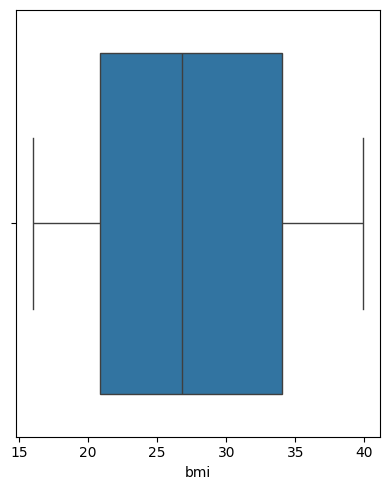

In [22]:
plt.figure(figsize=(4, 5))
sns.boxplot(data=df_cleaned, x="bmi")
plt.tight_layout()
plt.show()

In [23]:
# Percentile method

Lower_pct = 0.05
Upper_pct = 0.95

Lower_Bound_pct = df['bmi'].quantile(Lower_pct)
Upper_Bound_pct = df['bmi'].quantile(Upper_pct)

print("Lower Bound for BMI (Percentile Method):", Lower_Bound_pct)
print("Upper Bound for BMI (Percentile Method):", Upper_Bound_pct)
print()
print("normal range for BMI (Percentile Method):", Lower_Bound_pct, "to", Upper_Bound_pct)

Lower Bound for BMI (Percentile Method): 16.9
Upper Bound for BMI (Percentile Method): 39.1

normal range for BMI (Percentile Method): 16.9 to 39.1


# 4. Apply Winsorization

In [24]:
df['bmi_winsorized'] = df['bmi'].clip(lower=Lower_Bound_pct, upper=Upper_Bound_pct)

print(df['bmi_winsorized'].tolist())

print("Mean after : ", df['bmi_winsorized'].mean())
print("Mean before : ", df['bmi'].mean())

[33.3, 22.3, 38.8, 30.3, 16.9, 22.2, 26.8, 37.4, 23.4, 19.8, 20.2, 25.6, 39.1, 35.4, 25.4, 30.2, 26.2, 24.1, 17.1, 39.1, 34.3, 38.7, 24.6, 35.4, 20.6, 39.1, 19.2, 21.4, 16.9, 30.3, 31.0, 17.7, 19.8, 30.7, nan, 36.6, 20.4, 35.3, 21.7, 24.5, 21.1, 23.6, 19.4, 30.9, 21.2, 17.1, 34.0, 25.5, 25.2, 28.0, 29.5, 21.3, 25.6, 28.3, 35.8, 21.7, 20.8, 20.3, 29.1, 29.6, 34.2, 33.8, 32.1, 23.8, 16.9, 16.9, 21.4, 17.5, 34.9, nan, 36.0, 16.9, 28.3, 18.7, 29.1, 16.9, 35.5, 29.8, 34.6, 23.1, 34.3, 32.8, 39.0, 38.1, 17.9, 30.1, 16.9, 39.1, 39.1, 34.8, 18.9, 23.3, 18.7, 17.7, 25.0, 19.6, 20.0, 20.4, 17.5, 20.1, 32.9, 33.9, 23.1, 32.7, nan, 22.2, 22.3, 20.3, 18.2, 38.0, 31.4, 25.9, 35.5, 37.9, 31.3, 34.0, 37.3, 20.0, 36.8, 39.1, 35.8, 25.6, 35.4, 26.0, 39.1, 36.7, 21.2, 29.7, 16.9, 25.6, 17.3, 36.2, 18.8, 36.5, 36.3, 24.9, 31.5, 22.0, 18.3, nan, 32.2, 37.2, 36.3, 39.1, 33.5, 25.1, 31.0, 27.5, 23.2, 32.6, 31.2, 23.7, 22.6, 35.8, 38.7, 22.3, 36.8, 23.4, 39.1, 24.7, 18.9, 30.3, 27.0, 20.9, 18.4, 34.4, 26.4, 3

# 5. Compare dataset shape and summary

In [26]:
# Compare dataset shape
print("Shape Before Winsorization :", df.shape)
print("Shape After Winsorization  :", df_winsorized.shape)

# Compare summary statistics
print("\nSummary Before Winsorization")
print(df.describe().round(2))

print("\nSummary After Winsorization")
print(df_winsorized.describe().round(2))

Shape Before Winsorization : (1000, 10)


NameError: name 'df_winsorized' is not defined

## Part C : Final Clean Dataset 

### 6. cleaned dataset :

In [ ]:
# All missing values treated appropriately.

df_mean = df.copy()
df_freq = df.copy()
df_final = df.copy()
df_imput = df.copy()


In [ ]:
df_mean.to_csv('df_mean.csv', index=False)
df_freq.to_csv('df_freq.csv', index=False)
df_final.to_csv('df_final.csv', index=False)
df_imput.to_csv('df_imput.csv', index=False)

In [ ]:
# All outliers handled using suitable method

df_cleaned.to_csv('df_clean_by_Outliers.csv', index=False)


In [ ]:
df_clean_bmi.to_csv('df_clean_bmi.csv', index=False)

NameError: name 'df_clean_bmi' is not defined

### 7.Provide a brief report explaining : 

1. Which imputation strategy was most effective?

Answer:
The Mean Imputation method was the most effective for numerical columns because it filled missing values while maintaining the average of the data. For categorical columns, Mode Imputation was used because it replaced missing values with the most frequent category.

2. Which outlier handling method preserved data quality best?

Answer:
The Winsorization method preserved data quality the best. It reduced the effect of extreme values by capping them instead of deleting records, which helped maintain the dataset size and improve statistical analysis.

3. How did data cleaning improve dataset usability?

Answer:
Data cleaning improved the dataset by removing missing values, reducing the impact of outliers, and making the data more accurate and consistent. This resulted in better visualizations, more reliable analysis, and improved machine learning model performance.

These three answers are short, clear, and suitable for an assignment report.